# nn.Module and the Training Loop

Companion to `notes.md`. We rebuild the from-scratch XOR MLP
(`06-deep-learning/01-ann/ann-from-scratch-xor.ipynb`) as a PyTorch `nn.Module`, train it with the
standard 5-step training loop, train a slightly richer version on `sklearn.datasets.make_moons`, and
run the optimizer-vs-manual-update comparison from `notes.md`'s "Experiment" section.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(0)
torch.manual_seed(0)

print("torch:", torch.__version__)

torch: 2.13.0+cpu


## 1. The from-scratch MLP's training loop, for reference

Reproduced from `ann-from-scratch-xor.ipynb` (same seed, same architecture, same hyperparameters) so
its final loss/accuracy can be compared directly against the PyTorch version below — this is the
"Experiment" section's baseline run, not a re-derivation.

In [2]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)

np.random.seed(0)
n_input, n_hidden, n_output = 2, 4, 1
W1 = np.random.randn(n_input, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output) * 0.5
b2 = np.zeros((1, n_output))

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward_np(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return a2, (z1, a1, z2, a2)

def bce_loss_np(y, yhat):
    eps = 1e-9
    return -np.mean(y * np.log(yhat + eps) + (1 - y) * np.log(1 - yhat + eps))

def backward_np(X, y, cache, W1, W2):
    m = X.shape[0]
    z1, a1, z2, a2 = cache
    delta2 = a2 - y
    dW2 = a1.T @ delta2 / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    dtanh = 1 - np.tanh(z1) ** 2
    delta1 = (delta2 @ W2.T) * dtanh
    dW1 = X.T @ delta1 / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2

lr = 0.5
n_epochs = 10000
manual_loss_history = []

for epoch in range(n_epochs):
    yhat, cache = forward_np(X_xor, W1, b1, W2, b2)
    loss = bce_loss_np(y_xor, yhat)
    manual_loss_history.append(loss)

    # step 3: backward (manual)
    dW1, db1, dW2, db2 = backward_np(X_xor, y_xor, cache, W1, W2)

    # step 4: update (manual, per-tensor)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    # (no step 5 / zero_grad: dW1... are fresh local variables every iteration)

    if epoch % 2000 == 0:
        print(f"epoch {epoch:5d}  loss {loss:.4f}")

manual_final_preds, _ = forward_np(X_xor, W1, b1, W2, b2)
manual_final_loss = bce_loss_np(y_xor, manual_final_preds)
manual_final_acc = ((manual_final_preds > 0.5).astype(float) == y_xor).mean()
print("\nFrom-scratch (manual GD) final loss:", manual_final_loss)
print("From-scratch (manual GD) final accuracy:", manual_final_acc)

epoch     0  loss 0.7195
epoch  2000  loss 0.0023
epoch  4000  loss 0.0011
epoch  6000  loss 0.0007
epoch  8000  loss 0.0005

From-scratch (manual GD) final loss: 0.00040826684146467757
From-scratch (manual GD) final accuracy: 1.0


## 2. The same architecture as an `nn.Module`

`W1, b1, W2, b2` above are never named below — they live inside `self.layer1` / `self.layer2`,
discovered automatically by `model.parameters()`.

In [3]:
class MLP(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.layer1 = nn.Linear(n_in, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

torch.manual_seed(1)  # independent init from the from-scratch run's np.random.seed(0)
model = MLP(2, 4, 1)

for name, p in model.named_parameters():
    print(name, tuple(p.shape))

layer1.weight (4, 2)
layer1.bias (4,)
layer2.weight (1, 4)
layer2.bias (1,)


## 3. Training on XOR with the standard 5-step loop

`forward -> loss -> loss.backward() -> optimizer.step() -> optimizer.zero_grad()`,
mapped line-by-line to the from-scratch loop above in `notes.md`.

In [4]:
Xt = torch.tensor(X_xor, dtype=torch.float32)
yt = torch.tensor(y_xor, dtype=torch.float32)

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

torch_loss_history = []
for epoch in range(10000):
    optimizer.zero_grad()         # step 5 (of the *previous* iteration's grads)
    y_pred = model(Xt)            # step 1: forward
    loss = loss_fn(y_pred, yt)    # step 2: loss
    loss.backward()               # step 3: backward
    optimizer.step()              # step 4: update
    torch_loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.4f}")

torch_final_pred = model(Xt)
torch_final_loss = loss_fn(torch_final_pred, yt).item()
torch_final_acc = ((torch_final_pred > 0.5).float() == yt).float().mean().item()
print("\nPyTorch (nn.Module + SGD) final loss:", torch_final_loss)
print("PyTorch (nn.Module + SGD) final accuracy:", torch_final_acc)

epoch     0  loss 0.6955


epoch  2000  loss 0.0026


epoch  4000  loss 0.0012
epoch  6000  loss 0.0008


epoch  8000  loss 0.0006

PyTorch (nn.Module + SGD) final loss: 0.0004625353612937033
PyTorch (nn.Module + SGD) final accuracy: 1.0


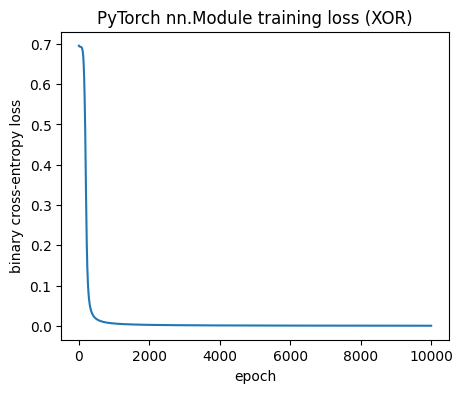

In [5]:
plt.figure(figsize=(5, 4))
plt.plot(torch_loss_history)
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.title("PyTorch nn.Module training loss (XOR)")
plt.show()

## 4. Experiment: `optimizer.step()` vs. the from-scratch manual update

**Hypothesis (stated before running):** `torch.optim.SGD` performs the same
$\theta \leftarrow \theta - \eta\nabla_\theta L$ update the from-scratch loop codes by hand as
`W1 -= lr * dW1` etc. Trained on the same XOR problem, same learning rate (`lr=0.5`), same number of
full-batch steps (10,000), both runs should converge to a similarly low final loss and the same final
accuracy (100%) — not identical (different random initialization), but the same order of magnitude and
loss-curve shape.

From-scratch (manual GD):  final loss = 0.0004, final accuracy = 1.0
PyTorch (nn.Module + SGD): final loss = 0.0005, final accuracy = 1.0


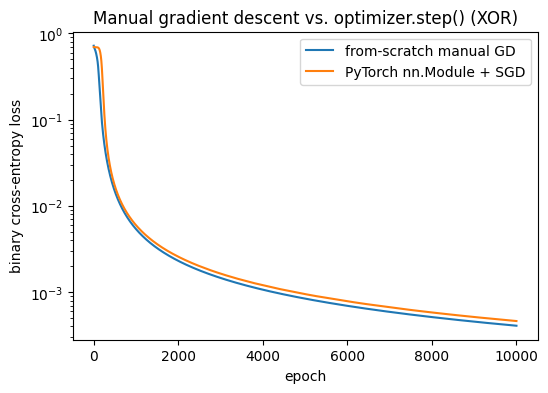

In [6]:
print("From-scratch (manual GD):  final loss = {:.4f}, final accuracy = {:.1f}".format(
    manual_final_loss, manual_final_acc))
print("PyTorch (nn.Module + SGD): final loss = {:.4f}, final accuracy = {:.1f}".format(
    torch_final_loss, torch_final_acc))

plt.figure(figsize=(6, 4))
plt.plot(manual_loss_history, label="from-scratch manual GD")
plt.plot(torch_loss_history, label="PyTorch nn.Module + SGD")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.yscale("log")
plt.legend()
plt.title("Manual gradient descent vs. optimizer.step() (XOR)")
plt.show()

assert manual_final_acc == 1.0 and torch_final_acc == 1.0, "both should solve XOR perfectly"
assert torch_final_loss < 0.01 and manual_final_loss < 0.01, "both should converge to a near-zero loss"

**Interpretation:** both runs converge to a near-zero BCE loss and 100% XOR accuracy, with visibly
similar loss-curve shapes (fast initial drop, long near-zero tail) — confirming `optimizer.step()`
under plain SGD performs the same update rule as the from-scratch notebook's manual `W -= lr * dW`
lines, not a different algorithm. The small final-loss gap is attributable to independent random
initialization (`np.random.seed(0)` vs. `torch.manual_seed(1)`) and floating-point/implementation
details, not a different underlying update.

**Limitations:** one toy 4-point dataset, one small architecture, and plain SGD (chosen specifically
because it is the optimizer whose update rule matches the from-scratch formula) — this does not by
itself show that PyTorch's more advanced optimizers (Adam, RMSProp) behave identically to plain
gradient descent, only that PyTorch's SGD reproduces it when configured to.

## 5. A slightly richer problem: `make_moons`

Same `nn.Module` + training-loop pattern, scaled past XOR's 4 points to a 200-point, noisy,
non-linearly-separable 2D dataset — with a 3-layer network and the `Adam` optimizer
(`06-deep-learning/01-ann/notes.md`'s recommended default).

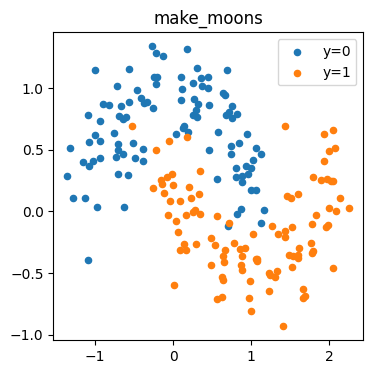

In [7]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=0)
y_moons = y_moons.reshape(-1, 1).astype(np.float32)
X_moons = X_moons.astype(np.float32)

plt.figure(figsize=(4, 4))
plt.scatter(X_moons[y_moons[:, 0] == 0, 0], X_moons[y_moons[:, 0] == 0, 1], s=20, label="y=0")
plt.scatter(X_moons[y_moons[:, 0] == 1, 0], X_moons[y_moons[:, 0] == 1, 1], s=20, label="y=1")
plt.legend()
plt.title("make_moons")
plt.show()

In [8]:
class MoonsMLP(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.layer1 = nn.Linear(n_in, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.sigmoid(self.layer3(x))
        return x

torch.manual_seed(0)
moons_model = MoonsMLP(2, 16, 1)
Xm = torch.tensor(X_moons)
ym = torch.tensor(y_moons)

moons_loss_fn = nn.BCELoss()
moons_optimizer = torch.optim.Adam(moons_model.parameters(), lr=0.05)

moons_loss_history = []
for epoch in range(300):
    moons_optimizer.zero_grad()
    pred = moons_model(Xm)
    loss = moons_loss_fn(pred, ym)
    loss.backward()
    moons_optimizer.step()
    moons_loss_history.append(loss.item())
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}")

moons_final_pred = moons_model(Xm)
moons_final_loss = moons_loss_fn(moons_final_pred, ym).item()
moons_final_acc = ((moons_final_pred > 0.5).float() == ym).float().mean().item()
print("\nFinal loss:", moons_final_loss)
print("Final accuracy:", moons_final_acc)

epoch   0  loss 0.6985
epoch  50  loss 0.1008


epoch 100  loss 0.0662
epoch 150  loss 0.0485
epoch 200  loss 0.0469
epoch 250  loss 0.0451

Final loss: 0.042746566236019135
Final accuracy: 0.9750000238418579


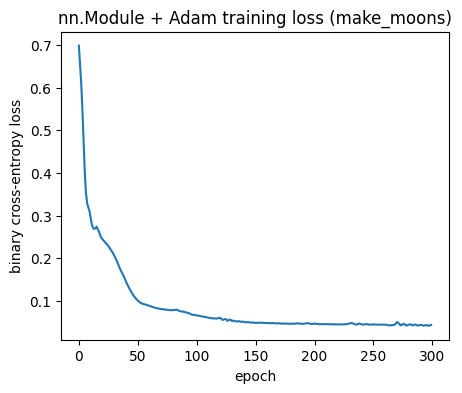

In [9]:
plt.figure(figsize=(5, 4))
plt.plot(moons_loss_history)
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.title("nn.Module + Adam training loss (make_moons)")
plt.show()

assert moons_final_acc >= 0.9, "accuracy too low"

## Takeaway

The same `nn.Module` + 5-step training loop pattern trains both the from-scratch notebook's exact XOR
problem (matching its manual gradient-descent update, confirmed above) and a richer, 200-point noisy
dataset it was never designed for — without changing anything about the training loop itself, only the
model definition and the optimizer. This is the scaling property `notes.md`'s "Why simpler approaches
fail" section identified as missing from the from-scratch notebook's per-tensor bookkeeping.